# MNIST

### MNIST 데이터 받기

In [1]:
import os
import sys
from six.moves import urllib
import gzip
import pickle
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt


SOURCE_URL = 'http://www.iro.umontreal.ca/~lisa/deep/data/mnist/mnist.pkl.gz'
FILENAME = SOURCE_URL.split('/')[-1]
DATA_DIR = './datasets'

def maybe_download(data_dir):
    filepath = os.path.join(data_dir, FILENAME)
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
    if not os.path.isfile(filepath):
        def _progress(count, block_size, total_size):
            sys.stdout.write('\r>> Downloading {} {:.1f} %'.format(
                FILENAME, float(count * block_size) / float(total_size) * 100.0))
            sys.stdout.flush()
        filepath, _ = urllib.request.urlretrieve(SOURCE_URL, filepath, _progress)
        print()
        statinfo = os.stat(filepath)
        print('Successfully donloaded', FILENAME, statinfo.st_size, 'bytes.')

def load(data_dir, subset='train'):
    maybe_download(data_dir)
    filepath = os.path.join(data_dir, FILENAME)
    
    f = gzip.open(filepath, 'rb')
    u = pickle._Unpickler(f)
    u.encoding = 'latin1'
    train_set, valid_set, test_set = u.load()
    f.close()
    
    if subset == 'train':
        trainx, trainy = train_set
        trainx = trainx.astype(np.float32).reshape(trainx.shape[0], 28, 28)
        trainy = trainy.astype(np.uint8)
        return trainx, trainy
    elif subset == 'test':
        testx, testy = test_set
        testx = testx.astype(np.float32).reshape(testx.shape[0], 28, 28)
        testy = testy.astype(np.uint8)
        return testx, testy
    elif subset== 'valid':
        validx, validy = valid_set
        validx = validx.astype(np.float32).reshape(validx.shape[0], 28, 28)
        validy = validy.astype(np.uint8)
        return validx, validy
    else:
        raise NotImplementedError('subset should be train or valid or test')

# Load data
train_data, train_label = load(DATA_DIR, 'train')
valid_data, valid_label = load(DATA_DIR, 'valid')
test_data, test_label = load(DATA_DIR, 'test')

# concatenate train and valid data as train data
train_data = np.concatenate((train_data, valid_data))
train_label = np.concatenate((train_label, valid_label))

### MNIST 데이터 확인 하기

In [2]:
# size of MNIST
print(train_data.shape)
print(train_label.shape)
print(test_data.shape)
print(test_label.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


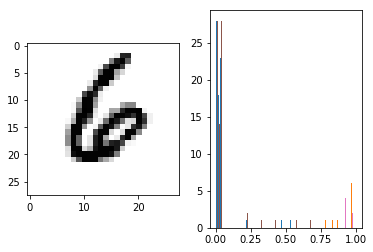

In [3]:
# show data
_, (ax1, ax2) = plt.subplots(1, 2)
sample_data = train_data[13]
ax1.imshow(sample_data, cmap=plt.cm.Greys);
ax2.hist(sample_data, bins=20, range=[0, 1]);

In [4]:
import tensorflow as tf
import random
import shutil

SUMMARY_DIR = './nonlinearMLP_summary'
TRAIN_DIR = SUMMARY_DIR + '/train'
TEST_DIR = SUMMARY_DIR + '/test'

if os.path.exists(SUMMARY_DIR):
    shutil.rmtree(SUMMARY_DIR)
if not os.path.exists(SUMMARY_DIR):
    os.makedirs(SUMMARY_DIR)
    os.makedirs(TRAIN_DIR)
    os.makedirs(TEST_DIR)

def get_next_batch(data, label, batch_size):
    n_data = data.shape[0]
    random_idx = random.sample(range(1, n_data), batch_size)
    
    batch_data = data[random_idx]
    batch_label = label[random_idx]
    return batch_data, batch_label

def get_one_hot(label):
    one_hot = np.zeros((label.shape[0], 10))
    one_hot[np.arange(label.shape[0]), label.astype(int)] = 1
    return one_hot

def fully_connected(inputs, out_channel, name='fc'):
    in_channel = inputs.get_shape().as_list()[1]
    w_shape = [in_channel, out_channel]
    b_shape = [out_channel]

    with tf.variable_scope(name):
        weights = tf.Variable(
            tf.truncated_normal(shape=w_shape, stddev=0.1), name='weights')
        biases = tf.Variable(tf.constant(0.1, shape=b_shape), name='biases')
        fc = tf.matmul(inputs, weights)
        fc = tf.nn.bias_add(fc, biases)
        
    return fc

def get_cross_entropy_loss(y_true, y_hat, epsilon=1e-8):
    with tf.name_scope('cross_entropy'):
        cross_entropy = tf.reduce_mean(-tf.reduce_sum(y_true * tf.log(y_hat + epsilon), axis=[1]))
    return cross_entropy

def get_accuracy(y_true, y_hat):
    with tf.name_scope('accuracy'):
        correct_prediction = tf.equal(tf.argmax(y_hat, 1), tf.argmax(y_true, 1), name='correct_prediction')
        accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32), name='accuracy')
    return accuracy

learning_rate = 0.5
max_iter = 5000
batch_size = 100
hidden = 256

train_data = train_data.reshape(-1, 784)
test_data = test_data.reshape(-1, 784)

train_label_hot = get_one_hot(train_label)
test_label_hot = get_one_hot(test_label)

x = tf.placeholder(tf.float32, [None, 784], name='x')
keep_prob = tf.placeholder(tf.float32, name='keep_prob')
y_true = tf.placeholder(tf.float32, [None, 10], name='y_true')

with tf.name_scope('nonlinearMLP'):
    h = fully_connected(x, hidden, name='fc1')
    h_relu = tf.nn.relu(h, name='fc1_relu')
    h_drop = tf.nn.dropout(h_relu, keep_prob, name='fc1_drop')
    y_logits = fully_connected(h_drop, 10, name='fc2')
    y_hat = tf.nn.softmax(y_logits, name='y_hat')

cross_entropy = get_cross_entropy_loss(y_true, y_hat)
accuracy = get_accuracy(y_true, y_hat)
train_step = tf.train.GradientDescentOptimizer(learning_rate).minimize(cross_entropy)

tf.summary.scalar('cross_entropy', cross_entropy)
tf.summary.scalar('accuracy', accuracy)
merged = tf.summary.merge_all()

init = tf.global_variables_initializer()

In [5]:
with tf.Session() as sess:
    train_writer = tf.summary.FileWriter(TRAIN_DIR, sess.graph)
    test_writer = tf.summary.FileWriter(TEST_DIR)
    
    sess.run(init)
    
    for step in range(max_iter):
        batch_x, batch_y = get_next_batch(train_data, train_label_hot, batch_size)
        _, loss, summary = sess.run([train_step, cross_entropy, merged], feed_dict={x: batch_x, y_true: batch_y, keep_prob: 0.7})
        train_writer.add_summary(summary, step)
        acc, summary = sess.run([accuracy, merged], feed_dict={x: test_data, y_true: test_label_hot, keep_prob: 1.0})
        test_writer.add_summary(summary, step)
        if (step + 1) % 10 == 0:
            print("{}th iteration, training loss: {:.4f}, test accuracy: {:.4f}".format(
            step + 1, loss, acc))

10th iteration, training loss: 0.8060, test accuracy: 0.7062
20th iteration, training loss: 0.9551, test accuracy: 0.7308
30th iteration, training loss: 0.4928, test accuracy: 0.8537
40th iteration, training loss: 0.6343, test accuracy: 0.8868
50th iteration, training loss: 0.3953, test accuracy: 0.9008
60th iteration, training loss: 0.5063, test accuracy: 0.9018
70th iteration, training loss: 0.3824, test accuracy: 0.8858
80th iteration, training loss: 0.4506, test accuracy: 0.9077
90th iteration, training loss: 0.4296, test accuracy: 0.9097
100th iteration, training loss: 0.4809, test accuracy: 0.9118
110th iteration, training loss: 0.4723, test accuracy: 0.9096
120th iteration, training loss: 0.2995, test accuracy: 0.9224
130th iteration, training loss: 0.2815, test accuracy: 0.9181
140th iteration, training loss: 0.4938, test accuracy: 0.9116
150th iteration, training loss: 0.4389, test accuracy: 0.9288
160th iteration, training loss: 0.2792, test accuracy: 0.9277
170th iteration, 

1330th iteration, training loss: 0.1298, test accuracy: 0.9721
1340th iteration, training loss: 0.1215, test accuracy: 0.9678
1350th iteration, training loss: 0.0915, test accuracy: 0.9720
1360th iteration, training loss: 0.2192, test accuracy: 0.9711
1370th iteration, training loss: 0.0601, test accuracy: 0.9710
1380th iteration, training loss: 0.2231, test accuracy: 0.9714
1390th iteration, training loss: 0.0871, test accuracy: 0.9681
1400th iteration, training loss: 0.0219, test accuracy: 0.9721
1410th iteration, training loss: 0.1142, test accuracy: 0.9670
1420th iteration, training loss: 0.0951, test accuracy: 0.9712
1430th iteration, training loss: 0.0957, test accuracy: 0.9702
1440th iteration, training loss: 0.0909, test accuracy: 0.9697
1450th iteration, training loss: 0.1739, test accuracy: 0.9689
1460th iteration, training loss: 0.1309, test accuracy: 0.9712
1470th iteration, training loss: 0.0593, test accuracy: 0.9694
1480th iteration, training loss: 0.1436, test accuracy:

2650th iteration, training loss: 0.1332, test accuracy: 0.9732
2660th iteration, training loss: 0.0490, test accuracy: 0.9723
2670th iteration, training loss: 0.0256, test accuracy: 0.9773
2680th iteration, training loss: 0.0905, test accuracy: 0.9768
2690th iteration, training loss: 0.1231, test accuracy: 0.9744
2700th iteration, training loss: 0.1153, test accuracy: 0.9752
2710th iteration, training loss: 0.0304, test accuracy: 0.9754
2720th iteration, training loss: 0.0621, test accuracy: 0.9774
2730th iteration, training loss: 0.0603, test accuracy: 0.9747
2740th iteration, training loss: 0.0180, test accuracy: 0.9774
2750th iteration, training loss: 0.0615, test accuracy: 0.9767
2760th iteration, training loss: 0.0591, test accuracy: 0.9747
2770th iteration, training loss: 0.0422, test accuracy: 0.9756
2780th iteration, training loss: 0.0470, test accuracy: 0.9756
2790th iteration, training loss: 0.0609, test accuracy: 0.9767
2800th iteration, training loss: 0.1219, test accuracy:

3970th iteration, training loss: 0.0189, test accuracy: 0.9778
3980th iteration, training loss: 0.0364, test accuracy: 0.9786
3990th iteration, training loss: 0.1379, test accuracy: 0.9779
4000th iteration, training loss: 0.0882, test accuracy: 0.9766
4010th iteration, training loss: 0.0653, test accuracy: 0.9786
4020th iteration, training loss: 0.1005, test accuracy: 0.9782
4030th iteration, training loss: 0.0711, test accuracy: 0.9764
4040th iteration, training loss: 0.1597, test accuracy: 0.9777
4050th iteration, training loss: 0.0560, test accuracy: 0.9780
4060th iteration, training loss: 0.0418, test accuracy: 0.9773
4070th iteration, training loss: 0.0429, test accuracy: 0.9792
4080th iteration, training loss: 0.0771, test accuracy: 0.9771
4090th iteration, training loss: 0.0229, test accuracy: 0.9784
4100th iteration, training loss: 0.0541, test accuracy: 0.9793
4110th iteration, training loss: 0.1277, test accuracy: 0.9792
4120th iteration, training loss: 0.0881, test accuracy: